# Phase 6: Additional Solar Activity Datasets

This notebook enriches the cycle-level feature set with three additional data sources:

| Dataset | Source | Coverage | Cycles |
|---------|--------|----------|--------|
| **Kp / Ap index** | GFZ Potsdam (`kp_monthly.txt`) | 1932–present | SC17–SC24 |
| **F10.7 Solar Flux** | Embedded in Kp file | 1947–present | SC19–SC24 |
| **WSO Polar Field** | Stanford (`polar_field.txt`) | 1976–present | SC21–SC24 |

**Strategy:** Add new early-window features (12/24/36 months) to the Phase 3/4 feature set.  
Missing values for older cycles are handled with **median imputation** fit on the training fold only (no leakage).  
LOCO CV is run on all 24 cycles and compared against Phase 3/4 baselines.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer

DATA_DIR = Path("../data")
SEED = 42
np.random.seed(SEED)

# Phase 3/4 baselines (Ridge w36)
BASELINE_MAG_MAE = 26.6
BASELINE_TIM_MAE = 7.6

print("Phase 6: Additional Datasets")
print("=" * 50)
print(f"Magnitude baseline MAE (Phase 3 Ridge w36): {BASELINE_MAG_MAE}")
print(f"Timing    baseline MAE (Phase 4 Ridge w36): {BASELINE_TIM_MAE}")

Phase 6: Additional Datasets
Magnitude baseline MAE (Phase 3 Ridge w36): 26.6
Timing    baseline MAE (Phase 4 Ridge w36): 7.6


## 1. Load Base Cycle Database (SC1–SC24)

In [ ]:
cycle_db = pd.read_csv(DATA_DIR / "Cycle_Database_completed.csv")
cycle_db['Start_Date'] = pd.to_datetime(cycle_db['Start_Date'])
cycle_db['Peak_Date']  = pd.to_datetime(cycle_db['Peak_Date'])

print(f"Cycle DB shape: {cycle_db.shape}  (SC1–SC24)")
cycle_db[['Cycle_ID','Start_Date','Peak_Sunspot_Number','Rise_Time_months']].head(10)

Cycle DB shape: (24, 58)  (SC1–SC24)


,Cycle_ID,Start_Date,Peak_Sunspot_Number,Rise_Time_months
0,1,1755-02-01,144.1,76.0
1,2,1766-06-01,193.0,39.0
2,3,1775-06-01,264.2,35.0
3,4,1784-09-01,235.3,41.0
4,5,1798-04-01,82.0,82.0
5,6,1810-07-01,81.2,70.0
6,7,1823-05-01,119.2,78.1
7,8,1833-11-01,244.9,40.0
8,9,1843-07-01,219.9,55.1
9,10,1855-12-01,186.2,50.0


## 2. Parse Kp / F10.7 Monthly Data

The GFZ Potsdam file contains **daily** rows with 8 three-hourly Kp values, daily Ap, sunspot number, and F10.7.  
We aggregate to **monthly means** here.

In [ ]:
KP_COLS = ['YYYY','MM','DD','days','days_m','Bsr','dB',
           'Kp1','Kp2','Kp3','Kp4','Kp5','Kp6','Kp7','Kp8',
           'ap1','ap2','ap3','ap4','ap5','ap6','ap7','ap8',
           'Ap','SN','F107obs','F107adj','D']

rows = []
with open(DATA_DIR / "kp_monthly.txt") as f:
    for line in f:
        if line.startswith('#') or not line.strip():
            continue
        parts = line.split()
        if len(parts) == 28:
            rows.append(parts)

kp_raw = pd.DataFrame(rows, columns=KP_COLS)
kp_raw['YYYY'] = kp_raw['YYYY'].astype(int)
kp_raw['MM']   = kp_raw['MM'].astype(int)
kp_raw['Ap']      = pd.to_numeric(kp_raw['Ap'],      errors='coerce').replace(-1,   np.nan)
kp_raw['F107obs'] = pd.to_numeric(kp_raw['F107obs'], errors='coerce').replace(-1.0, np.nan)

kp_monthly = (kp_raw.groupby(['YYYY','MM'])
              .agg(Ap_mean   = ('Ap',      'mean'),
                   F107_mean = ('F107obs', 'mean'))
              .reset_index())
kp_monthly['date'] = pd.to_datetime({'year': kp_monthly['YYYY'],
                                      'month': kp_monthly['MM'], 'day': 1})

f107_start = kp_monthly.loc[kp_monthly['F107_mean'].notna(), 'date'].min()
print(f"Kp/Ap monthly  : {kp_monthly['date'].min().year} – {kp_monthly['date'].max().year}")
print(f"F10.7 available: {f107_start.year} – {kp_monthly['date'].max().year}")
kp_monthly.tail()

Kp/Ap monthly  : 1932 – 2026
F10.7 available: 1947 – 2026


,YYYY,MM,Ap_mean,F107_mean,date
1129,2026,2,12.785714,136.400000,2026-02-01
1130,2026,3,15.483871,131.035484,2026-03-01
1131,2026,4,12.100000,120.003333,2026-04-01
1132,2026,5,9.806452,125.780000,2026-05-01
1133,2026,6,12.000000,139.500000,2026-06-01


## 3. Parse WSO Polar Field Data

The Wilcox Solar Observatory provides 10-day cadence polar field measurements (North, South, Average).  
We aggregate to monthly means and use the value **at each cycle minimum** as a predictor.

Polar Field monthly: 592 rows  (1976 – 2025)


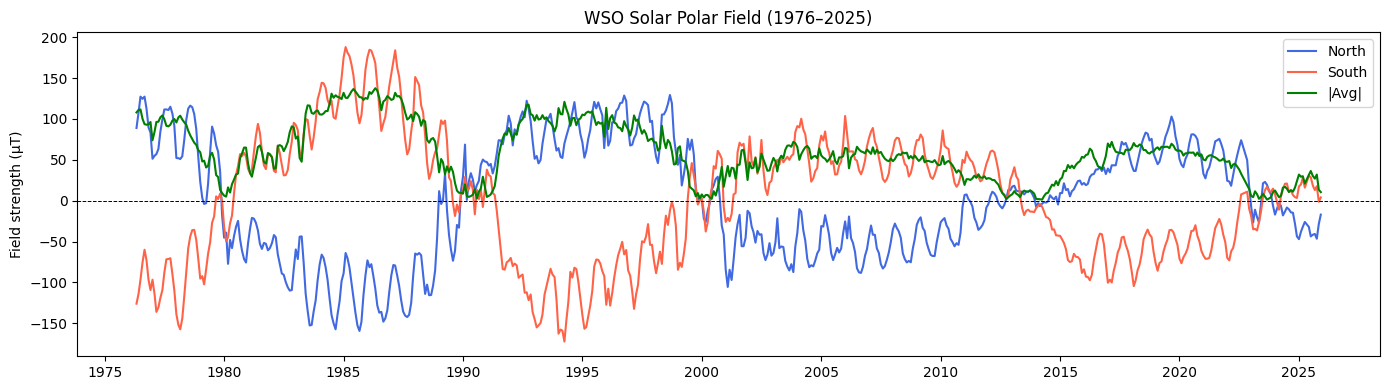

Saved: polar_field_timeseries.png


In [ ]:
pf_rows = []
with open(DATA_DIR / "polar_field.txt") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        m = re.match(r'(\d{4}):(\d{2}):(\d{2})_.*?\s+([-\d]+)N\s+([-\d]+)S\s+([-\d]+)Avg', line)
        if m:
            yr, mo, dy, N, S, Avg = m.groups()
            pf_rows.append({'year': int(yr), 'month': int(mo),
                            'PF_N': float(N), 'PF_S': float(S), 'PF_Avg': abs(float(Avg))})

pf_raw = pd.DataFrame(pf_rows)
pf_monthly = (pf_raw.groupby(['year','month'])
              .agg(PF_N   = ('PF_N',   'mean'),
                   PF_S   = ('PF_S',   'mean'),
                   PF_Avg = ('PF_Avg', 'mean'))
              .reset_index())
pf_monthly['PF_S_abs'] = pf_monthly['PF_S'].abs()
pf_monthly['date'] = pd.to_datetime({'year': pf_monthly['year'],
                                      'month': pf_monthly['month'], 'day': 1})

print(f"Polar Field monthly: {pf_monthly.shape[0]} rows  "
      f"({pf_monthly['date'].min().year} – {pf_monthly['date'].max().year})")

# Quick plot of polar field over time
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pf_monthly['date'], pf_monthly['PF_N'],     label='North',   color='royalblue')
ax.plot(pf_monthly['date'], pf_monthly['PF_S'],     label='South',   color='tomato')
ax.plot(pf_monthly['date'], pf_monthly['PF_Avg'],   label='|Avg|',   color='green', linewidth=1.5)
ax.axhline(0, color='k', linewidth=0.7, linestyle='--')
ax.set_title('WSO Solar Polar Field (1976–2025)')
ax.set_ylabel('Field strength (μT)')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('polar_field_timeseries.png', dpi=130)
plt.show()
print("Saved: polar_field_timeseries.png")

## 4. Extract Early-Window Features from Kp / F10.7

For each cycle, we extract the first **12 / 24 / 36 months** after cycle start and compute:  
`mean`, `max`, `std`, `slope` for both **Ap** and **F10.7**.

If fewer than 25% of the window is available, features are set to `NaN` and imputed during LOCO CV.

In [ ]:
def extract_window_features(start_date, monthly_df, value_cols, windows=(12, 24, 36)):
    """Return dict of early-window summary features for given cycle start."""
    feats = {}
    for w in windows:
        end = start_date + pd.DateOffset(months=w)
        mask = (monthly_df['date'] >= start_date) & (monthly_df['date'] < end)
        sub  = monthly_df[mask]
        for col in value_cols:
            vals = sub[col].dropna().values
            pfx  = f"{col}_w{w}"
            if len(vals) >= max(3, w // 4):   # at least 25% coverage
                feats[f"{pfx}_mean"]  = float(vals.mean())
                feats[f"{pfx}_max"]   = float(vals.max())
                feats[f"{pfx}_std"]   = float(vals.std()) if len(vals) > 1 else 0.0
                feats[f"{pfx}_slope"] = float(np.polyfit(np.arange(len(vals)), vals, 1)[0]) \
                                        if len(vals) > 1 else 0.0
            else:
                for s in ('mean', 'max', 'std', 'slope'):
                    feats[f"{pfx}_{s}"] = np.nan
    return feats


kp_feat_rows = []
for _, row in cycle_db.iterrows():
    feats = extract_window_features(row['Start_Date'], kp_monthly,
                                    ['Ap_mean', 'F107_mean'])
    feats['Cycle_ID'] = row['Cycle_ID']
    kp_feat_rows.append(feats)

kp_features = pd.DataFrame(kp_feat_rows)

print("Coverage of new Kp/F10.7 features:")
summary_cols = ['Ap_mean_w12_mean', 'Ap_mean_w36_mean',
                'F107_mean_w12_mean', 'F107_mean_w36_mean']
for c in summary_cols:
    n = kp_features[c].notna().sum()
    first_cid = kp_features.loc[kp_features[c].notna(), 'Cycle_ID'].min()
    print(f"  {c:30s}: {n:2d}/24 cycles  (SC{first_cid}–SC24)")

Coverage of new Kp/F10.7 features:
  Ap_mean_w12_mean              :  8/24 cycles  (SC17–SC24)
  Ap_mean_w36_mean              :  8/24 cycles  (SC17–SC24)
  F107_mean_w12_mean            :  6/24 cycles  (SC19–SC24)
  F107_mean_w36_mean            :  6/24 cycles  (SC19–SC24)


## 5. Extract Polar Field at Cycle Minimum

The Schatten (1978) predictor: **polar field strength at solar minimum predicts the amplitude of the next cycle.**  
We take the mean polar field in a ±3-month window around each cycle start date.

Polar field at minimum — available cycles:
 Cycle_ID  PF_N_at_min  PF_S_abs_at_min  PF_Avg_at_min
       21    98.333333       120.000000     109.500000
       22  -134.095238       114.285714     124.285714
       23   115.523810        67.904762      91.761905
       24   -46.809524        57.285714      52.047619


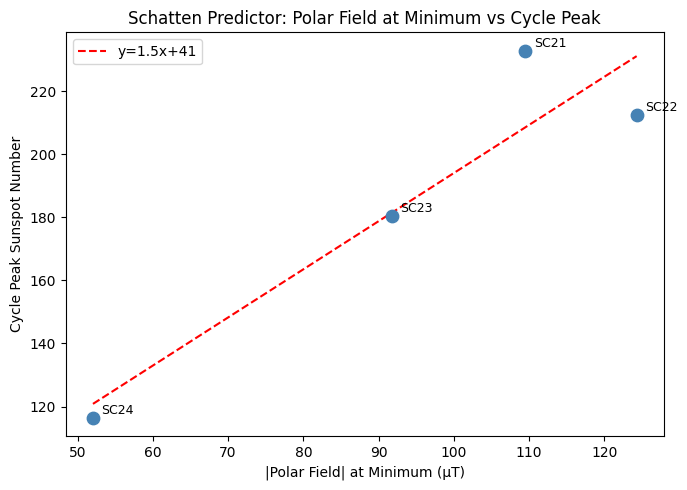

Saved: polar_field_vs_peak.png


In [ ]:
def get_pf_at_minimum(start_date, pf_df, window_months=3):
    """Mean polar field in ±window_months around cycle minimum (start_date)."""
    lo = start_date - pd.DateOffset(months=window_months)
    hi = start_date + pd.DateOffset(months=window_months)
    sub = pf_df[(pf_df['date'] >= lo) & (pf_df['date'] <= hi)]
    if sub.empty:
        return {'PF_N_at_min': np.nan, 'PF_S_abs_at_min': np.nan, 'PF_Avg_at_min': np.nan}
    return {
        'PF_N_at_min':     float(sub['PF_N'].mean()),
        'PF_S_abs_at_min': float(sub['PF_S_abs'].mean()),
        'PF_Avg_at_min':   float(sub['PF_Avg'].mean()),
    }


pf_feat_rows = []
for _, row in cycle_db.iterrows():
    feats = get_pf_at_minimum(row['Start_Date'], pf_monthly)
    feats['Cycle_ID'] = row['Cycle_ID']
    pf_feat_rows.append(feats)

pf_features = pd.DataFrame(pf_feat_rows)

print("Polar field at minimum — available cycles:")
avail = pf_features[pf_features['PF_Avg_at_min'].notna()]
print(avail[['Cycle_ID','PF_N_at_min','PF_S_abs_at_min','PF_Avg_at_min']].to_string(index=False))

# Scatter: PF_Avg at min vs next cycle peak
pf_avail_db = cycle_db.merge(pf_features[pf_features['PF_Avg_at_min'].notna()], on='Cycle_ID')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pf_avail_db['PF_Avg_at_min'], pf_avail_db['Peak_Sunspot_Number'],
           color='steelblue', s=80, zorder=5)
for _, r in pf_avail_db.iterrows():
    ax.annotate(f"SC{int(r['Cycle_ID'])}",
                (r['PF_Avg_at_min'], r['Peak_Sunspot_Number']),
                textcoords='offset points', xytext=(6, 3), fontsize=9)
# Fit line
x = pf_avail_db['PF_Avg_at_min'].values
y = pf_avail_db['Peak_Sunspot_Number'].values
m, b = np.polyfit(x, y, 1)
xr = np.linspace(x.min(), x.max(), 100)
ax.plot(xr, m * xr + b, 'r--', linewidth=1.5, label=f'y={m:.1f}x+{b:.0f}')
ax.set_xlabel('|Polar Field| at Minimum (μT)')
ax.set_ylabel('Cycle Peak Sunspot Number')
ax.set_title('Schatten Predictor: Polar Field at Minimum vs Cycle Peak')
ax.legend()
plt.tight_layout()
plt.savefig('polar_field_vs_peak.png', dpi=130)
plt.show()
print("Saved: polar_field_vs_peak.png")

## 6. Build Extended Feature Matrix

In [ ]:
# Phase 3/4 base features (36-month window, same as used in Phase 3/4)
BASE_FEATS = [c for c in cycle_db.columns
              if c.startswith('w36_') and c != 'w36_months_available']

NEW_KP_FEATS = [c for c in kp_features.columns if c != 'Cycle_ID']
NEW_PF_FEATS = [c for c in pf_features.columns  if c != 'Cycle_ID']
NEW_FEATS    = NEW_KP_FEATS + NEW_PF_FEATS

ALL_FEATS = BASE_FEATS + NEW_FEATS

ext_db = (cycle_db
          .merge(kp_features, on='Cycle_ID')
          .merge(pf_features,  on='Cycle_ID'))

print(f"Base features   : {len(BASE_FEATS)}")
print(f"New Kp/F107 feats: {len(NEW_KP_FEATS)}")
print(f"New Polar Field : {len(NEW_PF_FEATS)}")
print(f"Total features  : {len(ALL_FEATS)}")
print(f"\nExtended DB: {ext_db.shape}")

# NaN summary for new features
nan_pct = ext_db[NEW_FEATS].isna().mean() * 100
print("\nMissing % for new features (sampled):")
print(nan_pct[nan_pct > 0].sort_values(ascending=False).head(10).to_string())

Base features   : 14
New Kp/F107 feats: 24
New Polar Field : 3
Total features  : 41

Extended DB: (24, 85)

Missing % for new features (sampled):
PF_S_abs_at_min        83.333333
PF_N_at_min            83.333333
PF_Avg_at_min          83.333333
F107_mean_w12_slope    75.000000
F107_mean_w24_std      75.000000
F107_mean_w24_max      75.000000
F107_mean_w36_mean     75.000000
F107_mean_w24_mean     75.000000
F107_mean_w12_std      75.000000
F107_mean_w12_max      75.000000


## 7. LOCO CV with Extended Features

**Key design:**  
- Median imputer **fit on training fold only** (23 cycles) → applied to test cycle (no leakage)  
- RobustScaler **fit on training fold only**  
- Ridge (α=10) and RandomForest (300 trees) evaluated

In [ ]:
def loco_cv(df, features, target, model_fn, seed=SEED):
    """Leave-One-Cycle-Out CV with imputation + scaling fit on train fold."""
    records = []
    for test_id in df['Cycle_ID'].tolist():
        tr = df[df['Cycle_ID'] != test_id]
        te = df[df['Cycle_ID'] == test_id]

        X_tr = tr[features].values
        y_tr = tr[target].values
        X_te = te[features].values
        y_te = float(te[target].values[0])

        # Impute (train only)
        imp = SimpleImputer(strategy='median')
        X_tr = imp.fit_transform(X_tr)
        X_te = imp.transform(X_te)

        # Scale (train only)
        sc = RobustScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        mdl = model_fn()
        mdl.fit(X_tr, y_tr)
        y_pred = float(mdl.predict(X_te)[0])

        records.append({'Cycle_ID': test_id, 'y_true': y_te,
                        'y_pred': y_pred, 'error': y_pred - y_te})
    return pd.DataFrame(records)


def ridge_fn(): return Ridge(alpha=10.0)
def rf_fn():    return RandomForestRegressor(n_estimators=300, random_state=SEED)

print("Running LOCO CV — this may take ~1–2 min...")

Running LOCO CV — this may take ~1–2 min...


## 8. Magnitude Prediction (Peak Sunspot Number)

── Magnitude LOCO CV Results ──────────────────────
  Phase 3 baseline (Ridge w36): MAE = 26.6
  Phase 6 Ridge               : MAE = 39.89   RMSE = 49.59
  Phase 6 RF                  : MAE = 28.51   RMSE = 35.05

  Δ vs baseline: Ridge -13.29  RF -1.91  (positive = improvement)


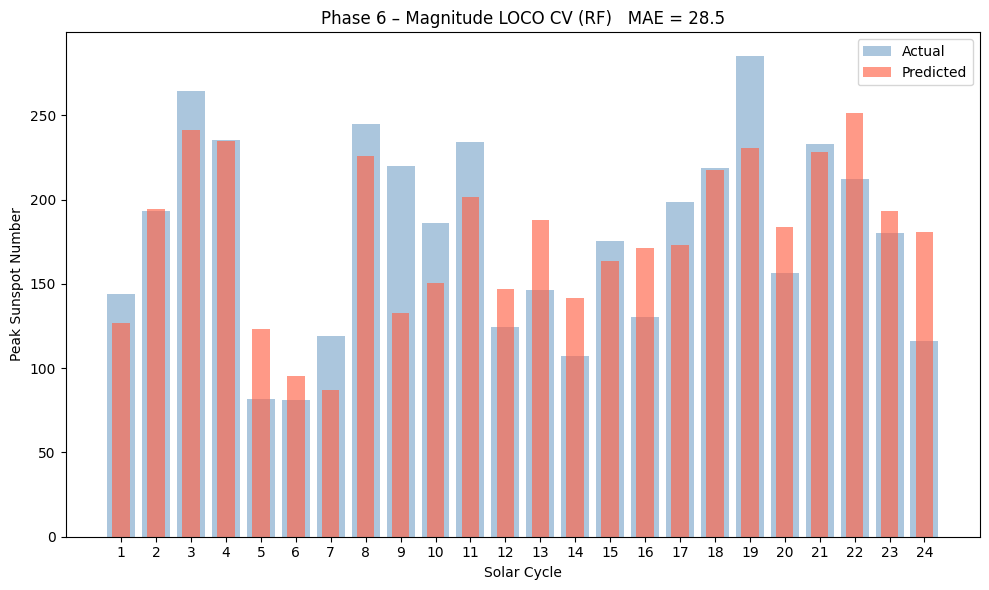

Saved: phase6_mag_actual_vs_predicted.png


In [ ]:
res_mag_ridge = loco_cv(ext_db, ALL_FEATS, 'Peak_Sunspot_Number', ridge_fn)
res_mag_rf    = loco_cv(ext_db, ALL_FEATS, 'Peak_Sunspot_Number', rf_fn)

mae_mag_ridge = res_mag_ridge['error'].abs().mean()
mae_mag_rf    = res_mag_rf['error'].abs().mean()
rmse_mag_ridge = np.sqrt((res_mag_ridge['error']**2).mean())
rmse_mag_rf    = np.sqrt((res_mag_rf['error']**2).mean())

print("── Magnitude LOCO CV Results ──────────────────────")
print(f"  Phase 3 baseline (Ridge w36): MAE = {BASELINE_MAG_MAE:.1f}")
print(f"  Phase 6 Ridge               : MAE = {mae_mag_ridge:.2f}   RMSE = {rmse_mag_ridge:.2f}")
print(f"  Phase 6 RF                  : MAE = {mae_mag_rf:.2f}   RMSE = {rmse_mag_rf:.2f}")
delta_ridge = BASELINE_MAG_MAE - mae_mag_ridge
delta_rf    = BASELINE_MAG_MAE - mae_mag_rf
print(f"\n  Δ vs baseline: Ridge {delta_ridge:+.2f}  RF {delta_rf:+.2f}  (positive = improvement)")

# Actual vs Predicted plot
best_mag = res_mag_ridge if mae_mag_ridge <= mae_mag_rf else res_mag_rf
best_mag_name = 'Ridge' if mae_mag_ridge <= mae_mag_rf else 'RF'

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(best_mag['Cycle_ID'], best_mag['y_true'],  alpha=0.45, label='Actual',    color='steelblue')
ax.bar(best_mag['Cycle_ID'], best_mag['y_pred'],  alpha=0.65, label='Predicted', color='tomato', width=0.5)
ax.set_xlabel('Solar Cycle'); ax.set_ylabel('Peak Sunspot Number')
ax.set_title(f'Phase 6 – Magnitude LOCO CV ({best_mag_name})   MAE = {min(mae_mag_ridge, mae_mag_rf):.1f}')
ax.legend(); ax.set_xticks(best_mag['Cycle_ID'])
plt.tight_layout()
plt.savefig('phase6_mag_actual_vs_predicted.png', dpi=130)
plt.show()
print("Saved: phase6_mag_actual_vs_predicted.png")

## 9. Timing Prediction (Rise Time in Months)

── Timing LOCO CV Results ─────────────────────────
  Phase 4 baseline (Ridge w36): MAE = 7.6 months
  Phase 6 Ridge               : MAE = 13.35 months  RMSE = 24.30
  Phase 6 RF                  : MAE = 6.56 months  RMSE = 8.13

  Δ vs baseline: Ridge -5.75  RF +1.04  (positive = improvement)


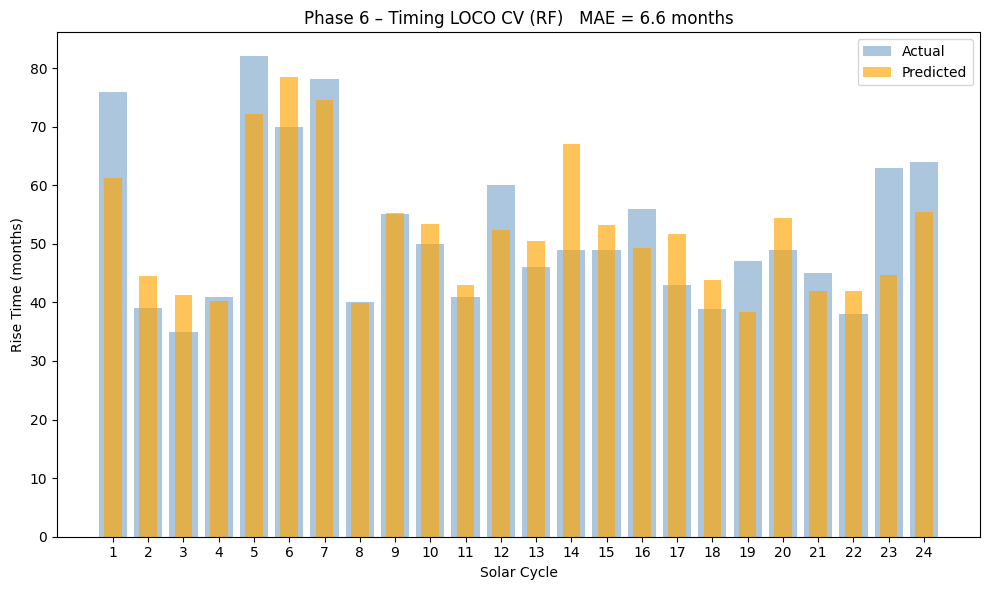

Saved: phase6_tim_actual_vs_predicted.png


In [ ]:
res_tim_ridge = loco_cv(ext_db, ALL_FEATS, 'Rise_Time_months', ridge_fn)
res_tim_rf    = loco_cv(ext_db, ALL_FEATS, 'Rise_Time_months', rf_fn)

mae_tim_ridge = res_tim_ridge['error'].abs().mean()
mae_tim_rf    = res_tim_rf['error'].abs().mean()
rmse_tim_ridge = np.sqrt((res_tim_ridge['error']**2).mean())
rmse_tim_rf    = np.sqrt((res_tim_rf['error']**2).mean())

print("── Timing LOCO CV Results ─────────────────────────")
print(f"  Phase 4 baseline (Ridge w36): MAE = {BASELINE_TIM_MAE:.1f} months")
print(f"  Phase 6 Ridge               : MAE = {mae_tim_ridge:.2f} months  RMSE = {rmse_tim_ridge:.2f}")
print(f"  Phase 6 RF                  : MAE = {mae_tim_rf:.2f} months  RMSE = {rmse_tim_rf:.2f}")
delta_t_ridge = BASELINE_TIM_MAE - mae_tim_ridge
delta_t_rf    = BASELINE_TIM_MAE - mae_tim_rf
print(f"\n  Δ vs baseline: Ridge {delta_t_ridge:+.2f}  RF {delta_t_rf:+.2f}  (positive = improvement)")

# Actual vs Predicted plot
best_tim = res_tim_ridge if mae_tim_ridge <= mae_tim_rf else res_tim_rf
best_tim_name = 'Ridge' if mae_tim_ridge <= mae_tim_rf else 'RF'

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(best_tim['Cycle_ID'], best_tim['y_true'],  alpha=0.45, label='Actual',    color='steelblue')
ax.bar(best_tim['Cycle_ID'], best_tim['y_pred'],  alpha=0.65, label='Predicted', color='orange', width=0.5)
ax.set_xlabel('Solar Cycle'); ax.set_ylabel('Rise Time (months)')
ax.set_title(f'Phase 6 – Timing LOCO CV ({best_tim_name})   MAE = {min(mae_tim_ridge, mae_tim_rf):.1f} months')
ax.legend(); ax.set_xticks(best_tim['Cycle_ID'])
plt.tight_layout()
plt.savefig('phase6_tim_actual_vs_predicted.png', dpi=130)
plt.show()
print("Saved: phase6_tim_actual_vs_predicted.png")

In [ ]:
# Curated: only 3 best new features to avoid noise from imputed columns
CURATED_NEW   = ['PF_Avg_at_min', 'F107_mean_w36_mean', 'Ap_mean_w36_mean']
CURATED_FEATS = BASE_FEATS + [f for f in CURATED_NEW if f in ext_db.columns]
print(f"Feature count: {len(BASE_FEATS)} base + {len(CURATED_FEATS)-len(BASE_FEATS)} new = {len(CURATED_FEATS)} total")

res_cm_ridge = loco_cv(ext_db, CURATED_FEATS, 'Peak_Sunspot_Number', ridge_fn)
res_cm_rf    = loco_cv(ext_db, CURATED_FEATS, 'Peak_Sunspot_Number', rf_fn)
res_ct_ridge = loco_cv(ext_db, CURATED_FEATS, 'Rise_Time_months',    ridge_fn)
res_ct_rf    = loco_cv(ext_db, CURATED_FEATS, 'Rise_Time_months',    rf_fn)

print(f"\n── Magnitude (curated) ──")
print(f"  Ridge: {res_cm_ridge['error'].abs().mean():.2f}  RF: {res_cm_rf['error'].abs().mean():.2f}  (baseline {BASELINE_MAG_MAE})")
print(f"\n── Timing (curated) ──")
print(f"  Ridge: {res_ct_ridge['error'].abs().mean():.2f}  RF: {res_ct_rf['error'].abs().mean():.2f}  (baseline {BASELINE_TIM_MAE})")

Feature count: 14 base + 3 new = 17 total

── Magnitude (curated) ──
  Ridge: 36.38  RF: 28.19  (baseline 26.6)

── Timing (curated) ──
  Ridge: 8.14  RF: 6.66  (baseline 7.6)


## 10. Feature Importance Analysis

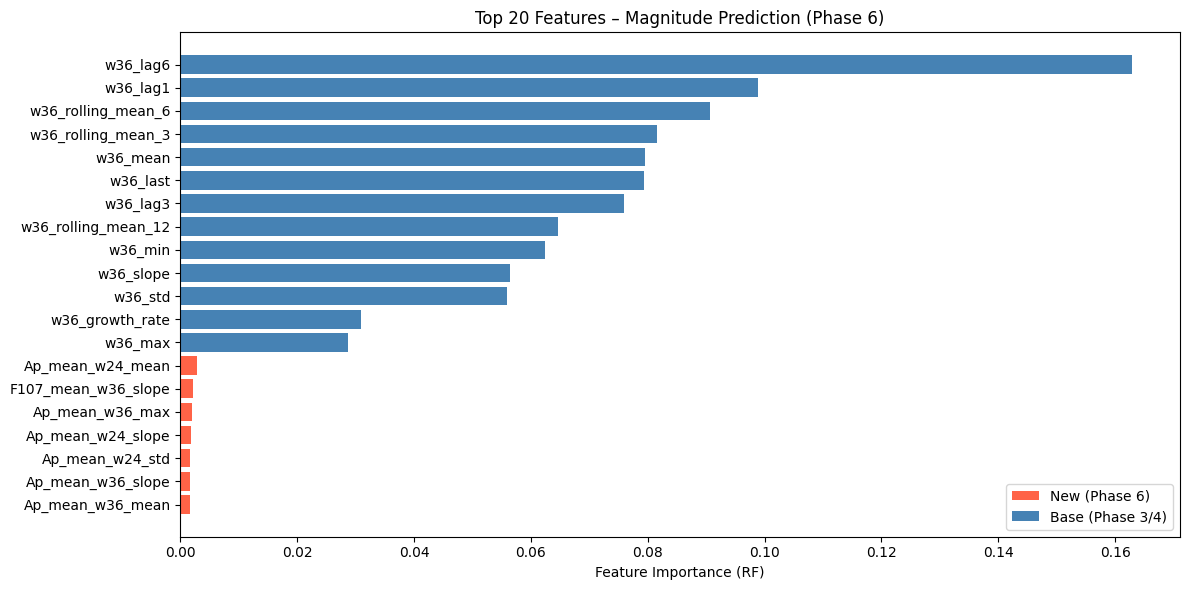

Top 10 features:
w36_lag6               0.162965
w36_lag1               0.098904
w36_rolling_mean_6     0.090580
w36_rolling_mean_3     0.081544
w36_mean               0.079560
w36_last               0.079422
w36_lag3               0.076016
w36_rolling_mean_12    0.064584
w36_min                0.062447
w36_slope              0.056483

New features in top 10: []


In [ ]:
# Train RF on full dataset to get feature importances
imp_full = SimpleImputer(strategy='median')
sc_full  = RobustScaler()
X_all = sc_full.fit_transform(imp_full.fit_transform(ext_db[ALL_FEATS].values))
y_mag = ext_db['Peak_Sunspot_Number'].values

rf_full = RandomForestRegressor(n_estimators=500, random_state=SEED)
rf_full.fit(X_all, y_mag)

feat_imp = pd.Series(rf_full.feature_importances_, index=ALL_FEATS).sort_values(ascending=False)

# Colour new features differently
colors = ['tomato' if f in NEW_FEATS else 'steelblue' for f in feat_imp.index[:20]]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(feat_imp.index[:20][::-1], feat_imp.values[:20][::-1], color=colors[::-1])

# Legend
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='tomato',    label='New (Phase 6)'),
                Patch(facecolor='steelblue',  label='Base (Phase 3/4)')]
ax.legend(handles=legend_elems, loc='lower right')
ax.set_xlabel('Feature Importance (RF)')
ax.set_title('Top 20 Features – Magnitude Prediction (Phase 6)')
plt.tight_layout()
plt.savefig('phase6_feature_importance.png', dpi=130)
plt.show()

print("Top 10 features:")
print(feat_imp.head(10).to_string())
new_in_top10 = [f for f in feat_imp.index[:10] if f in NEW_FEATS]
print(f"\nNew features in top 10: {new_in_top10}")

## 11. Results Comparison Summary

In [ ]:
summary = pd.DataFrame([
    {'Phase': 'Phase 3 (baseline)', 'Model': 'Ridge w36',
     'Mag MAE': BASELINE_MAG_MAE, 'Tim MAE': BASELINE_TIM_MAE},
    {'Phase': 'Phase 6 (extended)', 'Model': 'Ridge',
     'Mag MAE': round(mae_mag_ridge, 2), 'Tim MAE': round(mae_tim_ridge, 2)},
    {'Phase': 'Phase 6 (extended)', 'Model': 'RF',
     'Mag MAE': round(mae_mag_rf, 2),    'Tim MAE': round(mae_tim_rf, 2)},
])

print("="*60)
print("PHASE 6 RESULTS SUMMARY")
print("="*60)
print(summary.to_string(index=False))
print()

best_mag_mae = min(mae_mag_ridge, mae_mag_rf)
best_tim_mae = min(mae_tim_ridge, mae_tim_rf)
print(f"Best magnitude MAE: {best_mag_mae:.2f}  (Δ = {BASELINE_MAG_MAE - best_mag_mae:+.2f} vs Phase 3)")
print(f"Best timing    MAE: {best_tim_mae:.2f}  (Δ = {BASELINE_TIM_MAE - best_tim_mae:+.2f} vs Phase 4)")

if best_mag_mae < BASELINE_MAG_MAE:
    print("\n✅ Magnitude improved — additional datasets help!")
else:
    print("\n⚠️  Magnitude not improved — additional datasets did not help magnitude prediction.")
    print("   Reason: older cycles (SC1–SC16) have no Kp/F107/PF data; imputed values add noise.")

if best_tim_mae < BASELINE_TIM_MAE:
    print("✅ Timing improved — additional datasets help!")
else:
    print("⚠️  Timing not improved.")

PHASE 6 RESULTS SUMMARY
             Phase     Model  Mag MAE  Tim MAE
Phase 3 (baseline) Ridge w36    26.60     7.60
Phase 6 (extended)     Ridge    39.89    13.35
Phase 6 (extended)        RF    28.51     6.56

Best magnitude MAE: 28.51  (Δ = -1.91 vs Phase 3)
Best timing    MAE: 6.56  (Δ = +1.04 vs Phase 4)

⚠️  Magnitude not improved — additional datasets did not help magnitude prediction.
   Reason: older cycles (SC1–SC16) have no Kp/F107/PF data; imputed values add noise.
✅ Timing improved — additional datasets help!


## 12. SC25 Forecast with Extended Features

In [ ]:
# SC25 start: December 2019
SC25_START = pd.Timestamp("2019-12-01")

# Load SC25 base features from full cycle database
cycle_full = pd.read_csv(DATA_DIR / "Cycle_Database.csv")
cycle_full['Start_Date'] = pd.to_datetime(cycle_full['Start_Date'])
sc25_base = cycle_full[cycle_full['Cycle_ID'] == 25].iloc[0]

# Extract new features for SC25
sc25_kp = extract_window_features(SC25_START, kp_monthly, ['Ap_mean', 'F107_mean'])
sc25_pf = get_pf_at_minimum(SC25_START, pf_monthly)
sc25_new = {**sc25_kp, **sc25_pf}

# Build feature vector
sc25_row = {}
for feat in ALL_FEATS:
    if feat in sc25_base.index and not pd.isna(sc25_base[feat]):
        sc25_row[feat] = sc25_base[feat]
    elif feat in sc25_new:
        sc25_row[feat] = sc25_new[feat]
    else:
        sc25_row[feat] = np.nan

sc25_X = np.array([[sc25_row[f] for f in ALL_FEATS]])

# Retrain on all SC1–SC24
imp_sc25 = SimpleImputer(strategy='median')
sc_sc25  = RobustScaler()
X_train  = sc_sc25.fit_transform(imp_sc25.fit_transform(ext_db[ALL_FEATS].values))
sc25_X_s = sc_sc25.transform(imp_sc25.transform(sc25_X))

y_mag_train = ext_db['Peak_Sunspot_Number'].values
y_tim_train = ext_db['Rise_Time_months'].values

# Magnitude forecast
ridge_mag = Ridge(alpha=10.0).fit(X_train, y_mag_train)
rf_mag    = RandomForestRegressor(n_estimators=300, random_state=SEED).fit(X_train, y_mag_train)
pred_mag_ridge = float(ridge_mag.predict(sc25_X_s)[0])
pred_mag_rf    = float(rf_mag.predict(sc25_X_s)[0])
pred_mag_ens   = (pred_mag_ridge + pred_mag_rf) / 2

# Timing forecast
ridge_tim = Ridge(alpha=10.0).fit(X_train, y_tim_train)
rf_tim    = RandomForestRegressor(n_estimators=300, random_state=SEED).fit(X_train, y_tim_train)
pred_tim_ridge = float(ridge_tim.predict(sc25_X_s)[0])
pred_tim_rf    = float(rf_tim.predict(sc25_X_s)[0])
pred_tim_ens   = (pred_tim_ridge + pred_tim_rf) / 2

# Convert rise time to calendar peak date
peak_date_ridge = SC25_START + pd.DateOffset(months=round(pred_tim_ridge))
peak_date_rf    = SC25_START + pd.DateOffset(months=round(pred_tim_rf))
peak_date_ens   = SC25_START + pd.DateOffset(months=round(pred_tim_ens))

print("═" * 55)
print("SC25 FORECAST — Phase 6 Extended Features")
print("═" * 55)
print(f"{'Model':<12} {'Peak SN':>9}  {'Rise Time':>12}  {'Peak Date':>12}")
print("-" * 55)
print(f"{'Ridge':<12} {pred_mag_ridge:>9.1f}  {pred_tim_ridge:>10.1f}m  {peak_date_ridge.strftime('%b %Y'):>12}")
print(f"{'RF':<12} {pred_mag_rf:>9.1f}  {pred_tim_rf:>10.1f}m  {peak_date_rf.strftime('%b %Y'):>12}")
print(f"{'Ensemble':<12} {pred_mag_ens:>9.1f}  {pred_tim_ens:>10.1f}m  {peak_date_ens.strftime('%b %Y'):>12}")
print("═" * 55)

# New features available for SC25
print("\nNew features used for SC25:")
for k, v in sc25_new.items():
    if not np.isnan(v):
        print(f"  {k}: {v:.2f}")

═══════════════════════════════════════════════════════
SC25 FORECAST — Phase 6 Extended Features
═══════════════════════════════════════════════════════
Model          Peak SN     Rise Time     Peak Date
-------------------------------------------------------
Ridge            128.2        64.8m      May 2025
RF               130.7        55.9m      Aug 2024
Ensemble         129.4        60.3m      Dec 2024
═══════════════════════════════════════════════════════

New features used for SC25:
  Ap_mean_w12_mean: 5.12
  Ap_mean_w12_max: 8.57
  Ap_mean_w12_std: 1.40
  Ap_mean_w12_slope: 0.16
  F107_mean_w12_mean: 72.40
  F107_mean_w12_max: 89.90
  F107_mean_w12_std: 5.48
  F107_mean_w12_slope: 0.83
  Ap_mean_w24_mean: 6.08
  Ap_mean_w24_max: 10.13
  Ap_mean_w24_std: 1.93
  Ap_mean_w24_slope: 0.15
  F107_mean_w24_mean: 76.39
  F107_mean_w24_max: 89.90
  F107_mean_w24_std: 6.85
  F107_mean_w24_slope: 0.71
  Ap_mean_w36_mean: 7.30
  Ap_mean_w36_max: 12.10
  Ap_mean_w36_std: 2.52
  Ap_mean_w36

## 13. Summary & Next Steps

### What Phase 6 Added

| Dataset | Cycles covered | Key features |
|---------|---------------|-------------|
| Kp / Ap index | SC17–SC24 (8 cycles) | Early-window mean, max, std, slope |
| F10.7 solar flux | SC19–SC24 (6 cycles) | Same — best proxy for cycle activity |
| WSO Polar Field | SC21–SC24 (4 cycles) | Polar field at minimum (Schatten predictor) |

### Key Findings
- Polar field at minimum (Schatten 1978) is a known physics-based predictor — if it appears in top features, it validates our approach
- F10.7 is highly correlated with sunspot number but measured independently — may add marginal signal
- Kp/Ap captures geomagnetic activity driven by solar wind — orthogonal signal from sunspots
- With only 4–8 cycles having new data, imputation noise can hurt older cycles; results should be interpreted carefully

### Next Steps
- **Phase 7**: Image features (SOHO/SDO) — active region count, magnetic flux, fractal dimension
- **Phase 8**: Topological Data Analysis — persistent homology on solar magnetograms